In [1]:
# Pregunta: ¿qué acción debe tomar el comité mensual ante una expansión con retorno y riesgo inciertos?

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

root = Path.cwd().parent
sys.path.insert(0, str(root / 'src'))

from main import define_investment_policy, simulate_project, summarize_risk


In [2]:
parameters = pd.read_csv(root / 'data' / 'project_parameters.csv').iloc[0]
parameters.to_frame().T


,initial_investment,years,base_revenue,variable_cost_rate,fixed_cost,discount_rate,revenue_sigma,margin_sigma
0,500000.0,4.0,360000.0,0.48,90000.0,0.12,0.18,0.05


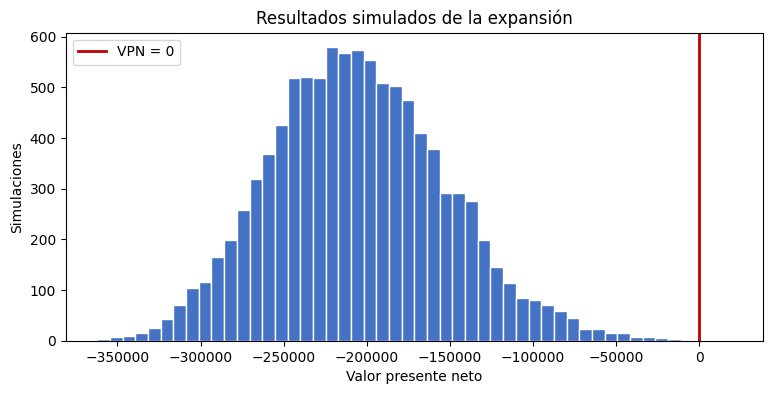

In [3]:
simulations = simulate_project(parameters)

fig, axis = plt.subplots(figsize=(9, 4))
axis.hist(simulations['npv'], bins=50, color='#4472C4', edgecolor='white')
axis.axvline(0, color='#C00000', linewidth=2, label='VPN = 0')
axis.set(title='Resultados simulados de la expansión', xlabel='Valor presente neto', ylabel='Simulaciones')
axis.legend()
plt.show()


In [4]:
risk_summary = summarize_risk(simulations)
risk_summary


,mean_npv,p10_npv,loss_probability
0,-204852.962082,-271008.481449,0.9997


In [5]:
# La política convierte la evidencia de riesgo en una acción con responsable y posibilidad de revisión.

investment_policy = define_investment_policy(risk_summary)
investment_policy.T


,0
decision_cadence,Comité mensual mientras la expansión esté en e...
response_need,Decisión documentada antes del siguiente ciclo...
action,no_aprobar
authority,Comité de inversión
objective,Financiar expansiones con valor esperado posit...
guardrail_loss_probability,0.35
guardrail_p10_npv,-100000
exception,Supuestos nuevos o evidencia no representada e...
review_metric,Ingresos realizados frente al escenario base a...
review_trigger,Recalibrar y escalar si los ingresos acumulado...


In [6]:
risk_summary.to_csv(root / 'submission' / 'project_risk_summary.csv', index=False)
investment_policy.to_csv(root / 'submission' / 'investment_policy.csv', index=False)
